# Compositional inference from repeated experiments

Suppose several experiments probe the same system. Each experiment is expensive to simulate, but all experiments share one parameter vector $\theta$. A conventional amortized posterior trained on $J$ experiments at once would require $J$ simulator calls for every training example and would be tied to that choice of $J$. Moreover, if simulating even a single experiment is expensive, simulate $J$ of them can quickly become a computational nightmare.

Compositional inference avoids this fixed panel. We train a diffusion posterior on **one experiment at a time**,

$$q_\phi(\theta\mid y_j),$$

and combine independently collected experiments only when data are observed. Applying Bayes' rule twice gives:

$$p(\theta\mid y_{1:J}) \propto p(\theta)^{1-J}\prod_{j=1}^J p(\theta\mid y_j).$$

A diffusion model represents each posterior through its score. At zero diffusion noise, products of densities become sums of scores, while the factor $p(\theta)^{1-J}$ prevents the prior from being counted $J$ times. Combining learned scores at intermediate noise levels is an approximation, so the resulting samples must be checked. One trained network can nevertheless combine two experiments or twenty without retraining.

This notebook isolates that idea. A small FitzHugh--Nagumo neuron receives different input currents. Every voltage trace is an independent experiment with the same two biophysical parameters. There are no subject-level parameters, no population distribution, and no ancestral sampling. We will:

1. train on individual voltage traces;
2. compose $2$, $4$, and $8$ traces;
3. compare the eight-trace result with the exact posterior on a grid.

> **Assumption.** The traces must be conditionally independent given $\theta$ and their known input currents.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import bayesflow as bf

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


In [12]:
N_TRAIN = 10_000
N_VALIDATION = 500
EPOCHS = 100
BATCH_SIZE = 256
N_POSTERIOR_SAMPLES = 512

## One simulator call, one experiment

The FitzHugh--Nagumo model is a simplified description of how an excitable cell, such as a neuron, responds to stimulation. It tracks two quantities over time:

$$\dot v = v - \frac{v^3}{3} - w + I, \qquad
\dot w = \frac{v + a - bw}{\tau}.$$

where $v(t)$ represents the cell's electrical response and is the quantity we observe with noise, and $w(t)$ is a slower, unobserved recovery state. The latter provides negative feedback that brings the voltage back down after excitation. $I$ is an externally applied input current. It is fixed during one experiment, but varies between experiments. The three parameters are:
- $a$ controls the cell's excitability by shifting the recovery dynamics.
- $b$ controls how strongly the current recovery state contributes to its own rate of change. We fix it at $b=0.8$.
- $\tau>0$ is the recovery time scale. A larger $\tau$ makes $w(t)$ change more slowly.

The nonlinear term $-v^3/3$ prevents the voltage from growing without bound, while the interaction between the fast voltage $v$ and slow recovery variable $w$ can produce spike-like responses. Each simulation starts from the same known state, $v(0)=-1$ and $w(0)=1$.

The two unknown quantities are collected in the parameter vector

$$\theta=(a,\log\tau).$$

We infer $\log\tau$ instead of $\tau$ so that every possible inferred value corresponds to a positive time scale through $\tau=\exp(\log\tau)$.

Experiment $j$ uses its own known current $I_j$. After solving the differential equations, we add measurement noise to the simulated voltage:

$$y_j(t) = v(t;\theta,I_j) + \epsilon_j(t), \qquad
\epsilon_j(t)\sim\mathcal N(0,\sigma_y^2).$$

Here, $j$ labels the experiment; $y_j(t)$ is its recorded voltage at time $t$; and $v(t;\theta,I_j)$ is the noise-free voltage obtained by solving the model with parameters $\theta$ and current $I_j$. The error $\epsilon_j(t)$ is a new independent Gaussian draw for every experiment and observation time. The notation $\mathcal N(0,\sigma_y^2)$ means a normal distribution with mean zero and variance $\sigma_y^2$; we use the noise standard deviation $\sigma_y=0.4$.

One simulator call therefore draws one parameter vector and one current, solves one voltage trajectory, keeps 21 time points, and adds independent measurement noise. The resulting network input has two channels at each observation time: the noisy voltage and the known current repeated along the trace. Including the current tells the network which stimulus produced the response; otherwise it could mistake a change in the experimental setting for a change in the neuron.

We use a Gaussian prior directly on $(a,\log\tau)$, the coordinates learned by the network. This makes the prior score available in closed form and avoids transforming parameters inside the compositional sampler.


In [4]:
TIME = np.linspace(0.0, 40.0, 161)
OBS_TIME = TIME[::8]
DT = TIME[1] - TIME[0]
B = 0.8
NOISE_SD = 0.4
CURRENT_LOW = 0.4
CURRENT_HIGH = 1.1

PRIOR_MEAN = np.array([0.70, np.log(12.5)])
PRIOR_SD = np.array([0.08, 0.18])

In [8]:
def sample_prior(n_simulations, rng):
    noise = rng.standard_normal((n_simulations, 2))
    return PRIOR_MEAN + PRIOR_SD * noise


def simulate_voltage(parameters, currents):
    """Euler simulation for a batch of parameter-current pairs."""
    a = parameters[:, 0]
    tau = np.exp(parameters[:, 1])
    voltage = np.empty((parameters.shape[0], TIME.size))
    recovery = np.empty_like(voltage)
    voltage[:, 0] = -1.0
    recovery[:, 0] = 1.0

    for step in range(TIME.size - 1):
        v = voltage[:, step]
        w = recovery[:, step]
        voltage[:, step + 1] = v + DT * (v - v**3 / 3.0 - w + currents)
        recovery[:, step + 1] = w + DT * (v + a - B * w) / tau

    return voltage


def observe(parameters, currents, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    voltage = simulate_voltage(parameters, currents)[:, ::8]
    noise = NOISE_SD * rng.standard_normal(voltage.shape)
    observables = np.empty(voltage.shape + (2,))
    observables[..., 0] = voltage + noise
    observables[..., 1] = currents[:, None]
    return observables


def simulate_dataset(n_simulations, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    parameters = sample_prior(n_simulations, rng)
    unit_uniform = rng.random(n_simulations)
    currents = CURRENT_LOW + (CURRENT_HIGH - CURRENT_LOW) * unit_uniform
    return {
        "parameters": parameters,
        "observables": observe(parameters, currents, rng),
    }

## The observations to be composed

For the demonstration, we fix one parameter vector and perform eight experiments at different currents. The traces have independent measurement noise. During training the network will never see such an eight-experiment panel: it sees only individual rows with shape `(time, channels)`.


In [9]:
TRUE_PARAMETERS = np.array([0.72, np.log(11.5)])
TEST_CURRENTS = np.linspace(0.45, 1.05, 8)
parameter_panel = np.repeat(TRUE_PARAMETERS[None, :], TEST_CURRENTS.size, axis=0)
observed_panel = observe(parameter_panel, TEST_CURRENTS)

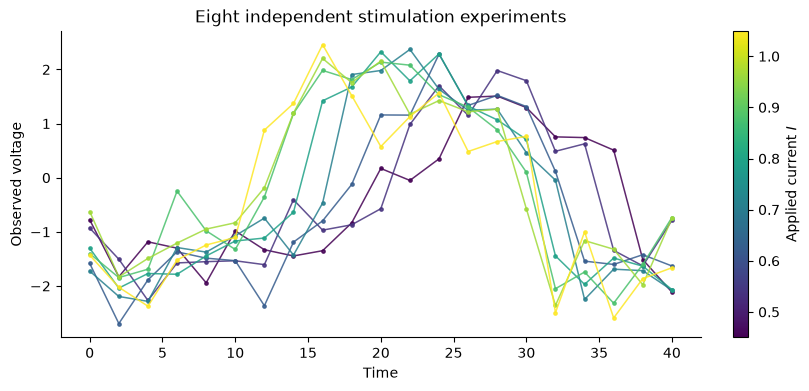

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
color_scale = plt.Normalize(TEST_CURRENTS.min(), TEST_CURRENTS.max())
colors = plt.cm.viridis(color_scale(TEST_CURRENTS))

for experiment, color in zip(observed_panel, colors):
    ax.plot(OBS_TIME, experiment[:, 0], color=color, linewidth=1.1, alpha=0.85, marker="o", markersize=2.4)
    
fig.colorbar(plt.cm.ScalarMappable(norm=color_scale, cmap="viridis"), ax=ax, label="Applied current $I$")
ax.set(xlabel="Time", ylabel="Observed voltage", title="Eight independent stimulation experiments")
ax.spines[["top", "right"]].set_visible(False)

## Train one local posterior

Each training pair contains one parameter draw and one voltage trace. The time-series network compresses the trace, and the diffusion model learns the local posterior score. Training on a single experiment is the only amortization step; composition does not fit another model.

We simulate 10,000 single-experiment training pairs, hold out 500 independent pairs for validation, and allow up to 80 epochs. Early stopping restores the best validation weights, so the plotted posterior is not based on an arbitrary final epoch.


In [ ]:
training_data = simulate_dataset(N_TRAIN)
validation_data = simulate_dataset(N_VALIDATION)

In [ ]:
workflow = bf.CompositionalWorkflow(
    inference_variables="parameters",
    summary_variables="observables",
    summary_network=bf.networks.RecurrentNetwork(hidden_dim=32),
    inference_network=bf.networks.DiffusionModel(subnet_kwargs={"widths": (128,)*3}),
    standardize="all"
)

In [ ]:
history = workflow.fit_offline(
    training_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

The held-out loss checks whether the local score model continues to improve on unseen single experiments. It is a training diagnostic, not a test of the composed posterior; that comparison comes below.


In [ ]:
fig = bf.diagnostics.loss(history)

## Add posterior scores, subtract repeated priors

For one experiment we use ordinary posterior sampling. For two or more, `compositional_sample` evaluates the learned score for every trace and combines the results. The function below supplies

$$\nabla_\theta \log p(\theta)
= -\frac{\theta-\mu_0}{\sigma_0^2}$$

for the independent Gaussian prior. BayesFlow handles the coordinate correction introduced by standardization. The condition array has shape `(datasets, experiments, time, channels)`; here there is one dataset and up to eight experiments.


In [ ]:
def prior_score(variables):
    parameters = variables["parameters"]
    return {"parameters": -(parameters - PRIOR_MEAN) / PRIOR_SD**2}

# Obtain posterior samples for first experiment (no composition)
posterior_by_experiment_count = {
    1: workflow.sample(
        conditions={"observables": observed_panel[None, 0]},
        num_samples=N_POSTERIOR_SAMPLES,
    )["parameters"][0]
}

# Obtain posterior samples for > 1 experiments (composition)
for n_experiments in (2, 4, 8):
    posterior_by_experiment_count[n_experiments] = workflow.compositional_sample(
        conditions={"observables": observed_panel[None, :n_experiments]},
        num_samples=N_POSTERIOR_SAMPLES,
        compute_prior_score=prior_score
    )["parameters"][0]


Every panel below plots the posterior learned by the same trained network. Only the number of score terms changes. The red samples are diffusion draws; the black contours enclose 50% and 90% of the exact posterior mass from the known observation model. This comparison shows approximation error as well as contraction.


In [ ]:
grid_size = 350
a_values = np.linspace(0.46, 0.94, grid_size)
log_tau_values = np.linspace(np.log(7.0), np.log(22.0), grid_size)
a_grid, log_tau_grid = np.meshgrid(a_values, log_tau_values)
grid_parameters = np.column_stack((a_grid.ravel(), log_tau_grid.ravel()))
log_posterior = -0.5 * np.sum(((grid_parameters - PRIOR_MEAN) / PRIOR_SD) ** 2, axis=1)
reference_by_experiment_count = {}

for index, experiment in enumerate(observed_panel, start=1):
    currents = np.full(grid_parameters.shape[0], experiment[0, 1])
    residual = experiment[:, 0] - simulate_voltage(grid_parameters, currents)[:, ::8]
    log_posterior -= np.sum(residual**2, axis=1) / (2.0 * NOISE_SD**2)
    if index in posterior_by_experiment_count:
        reference = np.exp(log_posterior - np.max(log_posterior)).reshape(a_grid.shape)
        reference_by_experiment_count[index] = reference / reference.sum()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True, layout="constrained")

for ax, (count, samples) in zip(axes.flat, posterior_by_experiment_count.items()):
    reference = reference_by_experiment_count[count]
    sorted_mass = np.sort(reference.ravel())[::-1]
    cumulative_mass = np.cumsum(sorted_mass)
    outer = sorted_mass[np.searchsorted(cumulative_mass, 0.90)]
    inner = sorted_mass[np.searchsorted(cumulative_mass, 0.50)]

    ax.contour(a_grid, np.exp(log_tau_grid), reference, levels=(outer, inner), colors="#202020", linewidths=(1.2, 1.8))
    ax.scatter(samples[:, 0], np.exp(samples[:, 1]), s=9, alpha=0.22, color="#2273b7", rasterized=True)
    ax.scatter(TRUE_PARAMETERS[0], np.exp(TRUE_PARAMETERS[1]), marker="*", s=115, color="#e08028", edgecolor="white", linewidth=0.5, zorder=5)
    ax.set(title=f"{count} experiment{'s' if count > 1 else ''}", xlim=(0.56, 0.80), ylim=(10.3, 14.5))
    ax.spines[["top", "right"]].set_visible(False)
    
for ax in axes[-1]:
    ax.set_xlabel(r"Excitability $a$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Time scale $\tau$")

fig.suptitle("Accumulating evidence: diffusion samples and exact posterior contours")


## Next steps

1. Free $\sigma_y$ by adding a proper prior and retrain the network. Explore parameters recovery and calibratin at $J = 8$ experiments.
2. Free also $b$ and check recovery / calibration. What did you observe?